In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout,Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
import cv2
from tensorflow.keras.callbacks import ReduceLROnPlateau
import os

Importing Dataset

In [2]:
#Importing Dataset
labels=['PNEUMONIA','NORMAL']
img_resize=150

def get_data(dir):
    data=[]
    for label in labels:
        path=os.path.join(dir,label)
        class_num=labels.index(label)

        for img in os.listdir(path):
            try:
                if img.lower().endswith((".jpeg", ".jpg", ".png")):
                    img_arr=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                    resized_arr= cv2.resize(img_arr,(img_resize,img_resize))
                    data.append([resized_arr,class_num])
            except Exception as e:
                print(e)
    return np.array(data,dtype='object')

train= get_data(r'D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\chest_xray\train')
test=get_data(r'D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\chest_xray\test')

Data Visulization and Preprocessing

In [3]:
print(f"Training Dataset:{train.shape}")
print(f"Test Dataset:{test.shape}")

Training Dataset:(5232, 2)
Test Dataset:(624, 2)


[Text(0, 0, '3883'), Text(0, 0, '1349')]

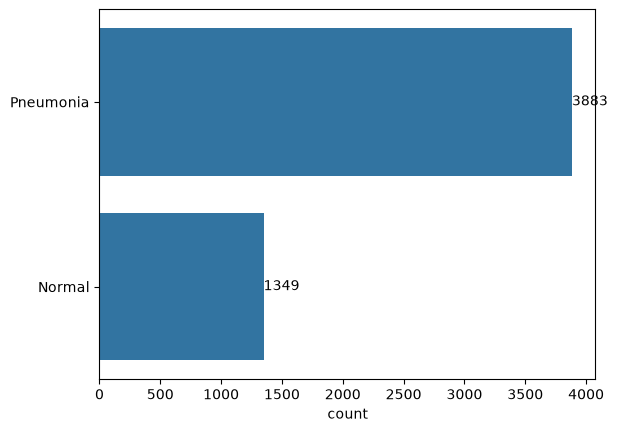

In [4]:
#Check for Imbalanced Data
l=[]
for i in train:
    if i[1]==0:
        l.append("Pneumonia")
    else:
        l.append("Normal")

ax=sns.countplot(l)
ax.bar_label(ax.containers[0])

Text(0.5, 1.0, 'NORMAL')

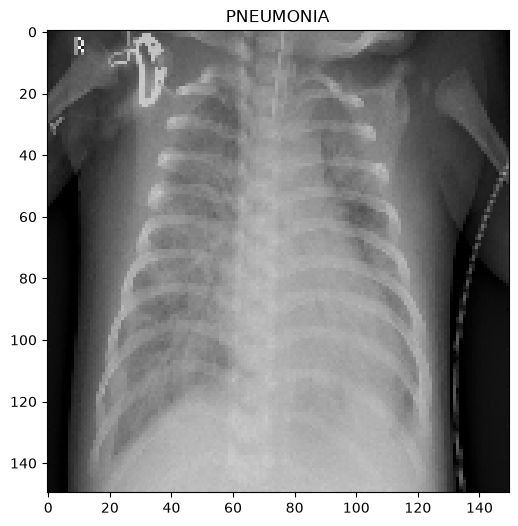

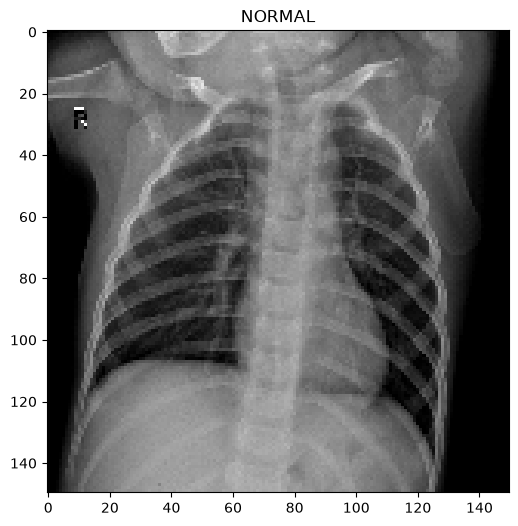

In [5]:
#Visualise Data
plt.figure(figsize=(6,6))
plt.imshow(train[0][0],cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-1][0],cmap='gray')
plt.title(labels[train[-1][1]])

In [6]:
#Split the Dataset
x_train=[]
y_train=[]

x_test=[]
y_test=[]

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

In [7]:
#Normalize the Dataset
x_train=np.array(x_train)/255
x_test=np.array(x_test)/255

x_train=x_train.reshape(-1,img_resize,img_resize,1)
x_test=x_test.reshape(-1,img_resize,img_resize,1)

y_train=np.array(y_train)
y_test=np.array(y_test)

In [8]:
#Splitting for Validation Data
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [9]:
#Data Augmentation
datagen= ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

In [10]:
print(f"Training Dataset:{x_train.shape}")
print(f"Test Dataset:{x_test.shape}")
print(f"Validation Dataset:{x_val.shape}")

Training Dataset:(4185, 150, 150, 1)
Test Dataset:(624, 150, 150, 1)
Validation Dataset:(1047, 150, 150, 1)


Training CNN

In [11]:
def CNN_Model():
    model= Sequential()
    model.add(tf.keras.layers.Input(shape=(150,150,1)))
    model.add(Conv2D(32,(3,3),strides=1,padding='same',activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2),strides=2,padding='same'))

    model.add(Conv2D(64,(3,3),strides=1,padding='same',activation='relu'))
    model.add(Dropout(0.1))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2),strides=2,padding='same'))

    model.add(Conv2D(64,(3,3),strides=1,padding='same',activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2),strides=2,padding='same'))

    model.add(Conv2D(128,(3,3),strides=1,padding='same',activation='relu'))
    model.add(Dropout(0.2))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2),strides=2,padding='same'))

    model.add(Conv2D(256,(3,3),strides=1,padding='same',activation='relu'))
    model.add(Dropout(0.2))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2),strides=2,padding='same'))

    model.add(Flatten())  
    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1,activation='sigmoid'))

    return model

model= CNN_Model()

print(model.summary())




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

None


In [12]:
#Compiling the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
        ]
)

#Learning Rate Scheduler
lr_reduction=ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=0.0000001
)

#Early Stopping Criteria
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#Save Best Model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_pneumonia_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

callbacks=[
    early_stop,
    lr_reduction,
    checkpoint
]

In [13]:
history=model.fit(
    datagen.flow(x_train,y_train, batch_size=32,),
    epochs=18,
    validation_data=(x_val,y_val),
    callbacks=callbacks
)

Epoch 1/18
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8499 - auc: 0.9106 - loss: 0.4320 - precision: 0.7299 - recall: 0.6636
Epoch 1: val_auc improved from None to 0.50000, saving model to best_pneumonia_model.keras

Epoch 1: finished saving model to best_pneumonia_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 423ms/step - accuracy: 0.8499 - auc: 0.9106 - loss: 0.4320 - precision: 0.7299 - recall: 0.6636 - val_accuracy: 0.7421 - val_auc: 0.5000 - val_loss: 8.6994 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/18
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9106 - auc: 0.9580 - loss: 0.2323 - precision: 0.8255 - recall: 0.8285
Epoch 2: val_auc did not improve from 0.50000
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 440ms/step - accuracy: 0.9106 - auc: 0.9580 - loss: 0.2323 - precision: 0.8255 - recall: 0.8285 - val_accuracy: 0.7421 - val_auc: 0.5000 - val_loss: 9.4016 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate

>Evaluation

In [14]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(x_test,y_test,verbose=0)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test AUC      : {test_auc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.8526
Test Precision: 0.9610
Test Recall   : 0.6325
Test AUC      : 0.9485
Test Loss     : 0.4102


Text(0, 0.5, 'Loss')

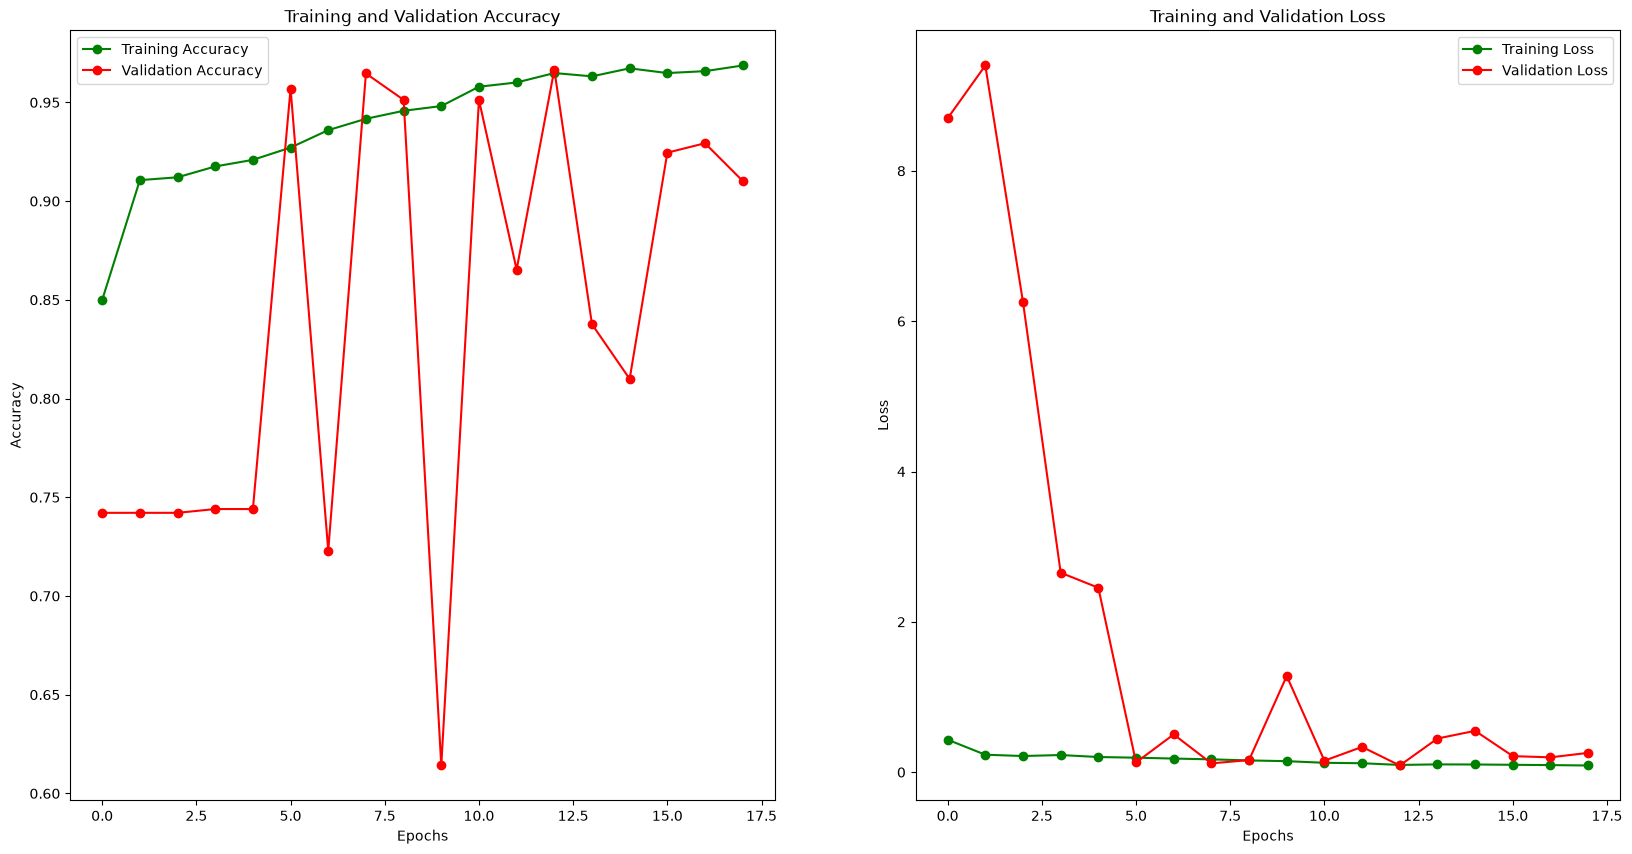

In [15]:
epochs=[i for i in range(18)]
fig,ax= plt.subplots(1,2)
train_acc=history.history['accuracy']
train_loss=history.history["loss"]
val_accuracy=history.history["val_accuracy"]
val_loss=history.history["val_loss"]

fig.set_size_inches(20,10)

ax[0].plot(epochs,train_acc,'go-',label='Training Accuracy')
ax[0].plot(epochs,val_accuracy,'ro-',label='Validation Accuracy')
ax[0].set_title("Training and Validation Accuracy")
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs,train_loss,'go-',label='Training Loss')
ax[1].plot(epochs,val_loss,'ro-',label='Validation Loss')
ax[1].set_title("Training and Validation Loss")
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

Model Analysis

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step


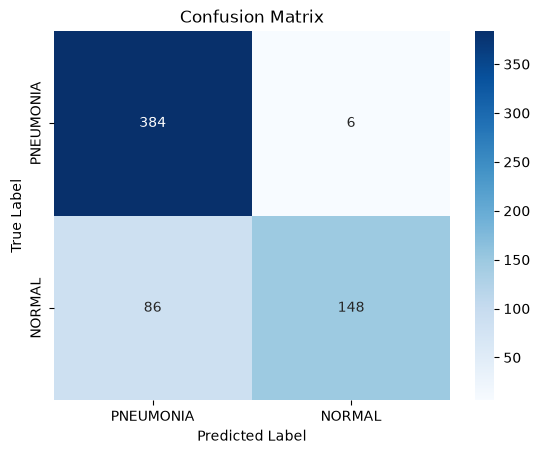

In [20]:
y_pred_prob=model.predict(x_test)
y_pred=(y_pred_prob>0.5).astype(int)

y_pred=y_pred.flatten()
y_true=y_test.flatten()

cm=confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['PNEUMONIA','NORMAL'],yticklabels=['PNEUMONIA','NORMAL'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['PNEUMONIA','NORMAL']
))

              precision    recall  f1-score   support

   PNEUMONIA       0.82      0.98      0.89       390
      NORMAL       0.96      0.63      0.76       234

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



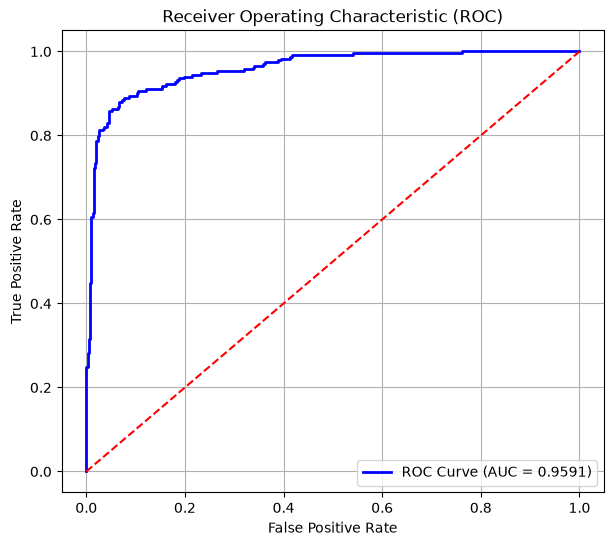

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    color='blue',
    lw=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    color='red',
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

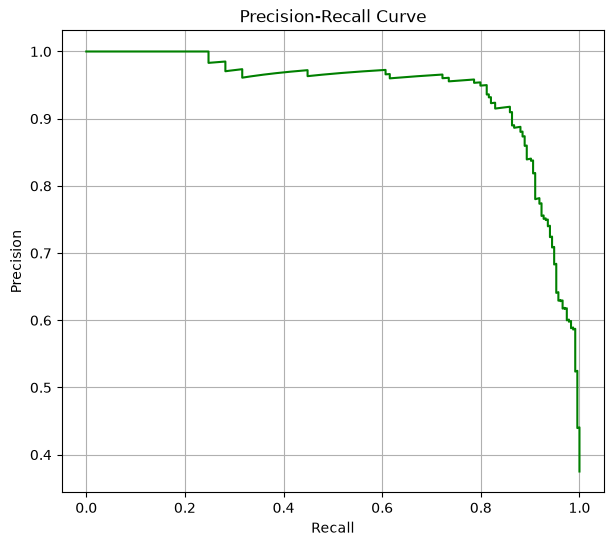

In [19]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_true,
    y_pred_prob
)

plt.figure(figsize=(7,6))

plt.plot(recall, precision, color='green')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

>Best Model was at EPOCH 13

In [22]:
best_model=tf.keras.models.load_model('best_pneumonia_model.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,737,029 (14.26 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

 Optimizer params: 2,490,628 (9.50 MB)